In [4]:
# Import required modules
import datetime
from datetime import timedelta
import geopandas as gpd

%matplotlib notebook

import matplotlib.pyplot as plt
import numpy as np

import pandas as pd
from pprint import pprint
from shapely.geometry import Point

import warnings
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
from adjustText import adjust_text 

# Add that all figures should be inlined
%matplotlib inline

## Read data

In [7]:
catchment = "tuolumne"
swe_observations_path = f'/anvil/projects/x-ees240082/users/dcasson/gpep/{catchment}/snow_data/{catchment}_NorSWE.nc'
basin_gpkg_path = f'/anvil/projects/x-ees240082/users/dcasson/gpep/{catchment}/gis/{catchment}_tdx.gpkg'
hru_csv_path = f'/anvil/projects/x-ees240082/users/dcasson/gpep/{catchment}/gis/stations_with_hru_ids.csv' 
start_date = '2008-10-01'
end_date = '2018-10-01'


In [8]:
def filter_stations_by_obs_per_year(ds, var='snw', n=1, start_date='2008-10-01', end_date='2021-12-31'):
    """
    Filters stations based on a minimum number of valid observations per year for a given variable.

    Parameters:
        ds (xarray.Dataset): Dataset with dimensions (time, station_id)
        var (str): Variable to check (e.g., 'snw')
        n (int): Minimum number of valid observations per year
        start_date (str): Start date for filtering
        end_date (str): End date for filtering

    Returns:
        xarray.Dataset: Dataset filtered to include only qualifying station_ids
    """
    # 1. Restrict to desired time range
    ds_filtered = ds.sel(time=slice(start_date, end_date))

    # 2. Identify valid observations (non-NaN)
    valid = ~ds_filtered[var].isnull()

    # 3. Extract years using .dt accessor
    years = ds_filtered.time.dt.year

    # 4. Group by year and sum valid obs per station per year
    obs_per_year = valid.groupby(xr.DataArray(years, coords={"time": ds_filtered.time}, dims="time").rename("year")).sum(dim="time")

    # 5. Check that all years for a station meet the n threshold
    station_mask = (obs_per_year >= n).all(dim="year")

    # 6. Apply mask to original filtered dataset
    return ds_filtered.sel(station_id=ds_filtered.station_id[station_mask])

<xarray.Dataset> Size: 4MB
Dimensions:        (station_id: 8, time: 15706)
Coordinates:
  * time           (time) datetime64[ns] 126kB 1979-01-01 ... 2021-12-31
  * station_id     (station_id) <U13 416B 'NRCS-CA-RFM' ... 'NOHRSC-CA147'
Data variables: (12/14)
    lat            (station_id) float32 32B ...
    lon            (station_id) float32 32B ...
    elevation      (station_id) float32 32B ...
    source         (station_id) <U41 1kB ...
    station_name   (station_id) <U33 1kB ...
    type_mes       (station_id) uint8 8B ...
    ...             ...
    snd            (time, station_id) float32 503kB ...
    den            (time, station_id) float32 503kB ...
    data_flag_snw  (time, station_id) <U2 1MB ...
    data_flag_snd  (time, station_id) <U1 503kB ...
    qc_flag_snw    (time, station_id) <U1 503kB ...
    qc_flag_snd    (time, station_id) <U1 503kB ...
Attributes:
    Conventions:    CF-1.9
    Title:          Northern Hemisphere in situ SWE 1979-2021 v3
    Latest_upda

<xarray.Dataset> Size: 29kB
Dimensions:        (station_id: 0, time: 3653)
Coordinates:
  * time           (time) datetime64[ns] 29kB 2008-10-01 ... 2018-10-01
  * station_id     (station_id) <U13 0B 
Data variables: (12/14)
    lat            (station_id) float32 0B ...
    lon            (station_id) float32 0B ...
    elevation      (station_id) float32 0B ...
    source         (station_id) <U41 0B ...
    station_name   (station_id) <U33 0B ...
    type_mes       (station_id) uint8 0B ...
    ...             ...
    snd            (time, station_id) float32 0B ...
    den            (time, station_id) float32 0B ...
    data_flag_snw  (time, station_id) <U2 0B ...
    data_flag_snd  (time, station_id) <U1 0B ...
    qc_flag_snw    (time, station_id) <U1 0B ...
    qc_flag_snd    (time, station_id) <U1 0B ...
Attributes:
    Conventions:    CF-1.9
    Title:          Northern Hemisphere in situ SWE 1979-2021 v3
    Latest_update:  April 2025
    Source:         Environment and Climate Change Canada and partners (https...
    Distribution:   CanSWE data are redistributed under the Open Government L...
    Comment:        See Vionnet et al. (ESSD, 2021) for a description of the ...

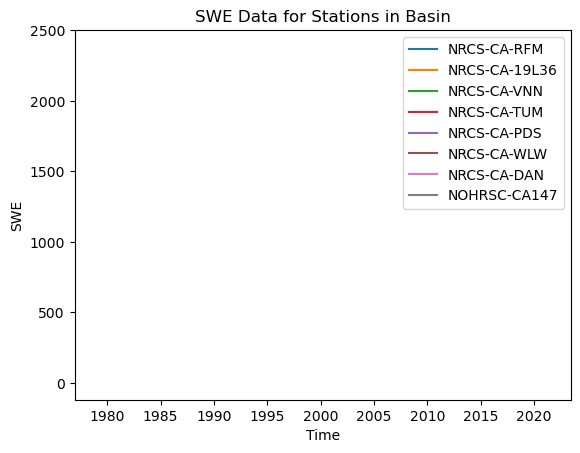

[46. 73. 88. 95. 88. 88. 25. 89.]


In [9]:
# Read SWE station observations NetCDF
SWE_stations_ds_complete = xr.open_dataset(swe_observations_path)
print(SWE_stations_ds_complete)

SWE_stations_ds = filter_stations_by_obs_per_year(SWE_stations_ds_complete, var='snw', n=2, start_date=start_date, end_date=end_date)
display(SWE_stations_ds)
SWE_stations_ds = SWE_stations_ds_complete
# Plot the SWE data for the stations in the basin
plt.plot(SWE_stations_ds.time, SWE_stations_ds.snw, label=SWE_stations_ds.station_id.values)
plt.title('SWE Data for Stations in Basin')
plt.xlabel('Time')
plt.ylabel('SWE')
plt.legend()
plt.show()

#Read hru ids csv
hru_ids = pd.read_csv(hru_csv_path)

# Match the station_id to return the gru_id
gru_ids = hru_ids[hru_ids['station_id'].isin(SWE_stations_ds.station_id.values)]['GRU_ID'].values
print(gru_ids)


You can zoom into the map with the rectangle icon ("zoom to rectangle") showing below the figure. Here, you see that the sample data contains SWE station observations for an area around two river basins, one in the USA and one in Canada, for which we also have all the data needed to run this workflow (e.g., discharge observations).

We will now extract the SWE station observations in the test basin and make a few plots.

GRU_ID: 046


/tmp/ipykernel_3779538/3416380263.py:49: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 500. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(path, chunks={'time': 500})
/tmp/ipykernel_3779538/3416380263.py:49: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 500. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(path, chunks={'time': 500})
/tmp/ipykernel_3779538/3416380263.py:49: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 500. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(path, chunks={'time': 500})
/tmp/ipykernel_3779538/3416380263.py:49: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 500. This could degrade performa

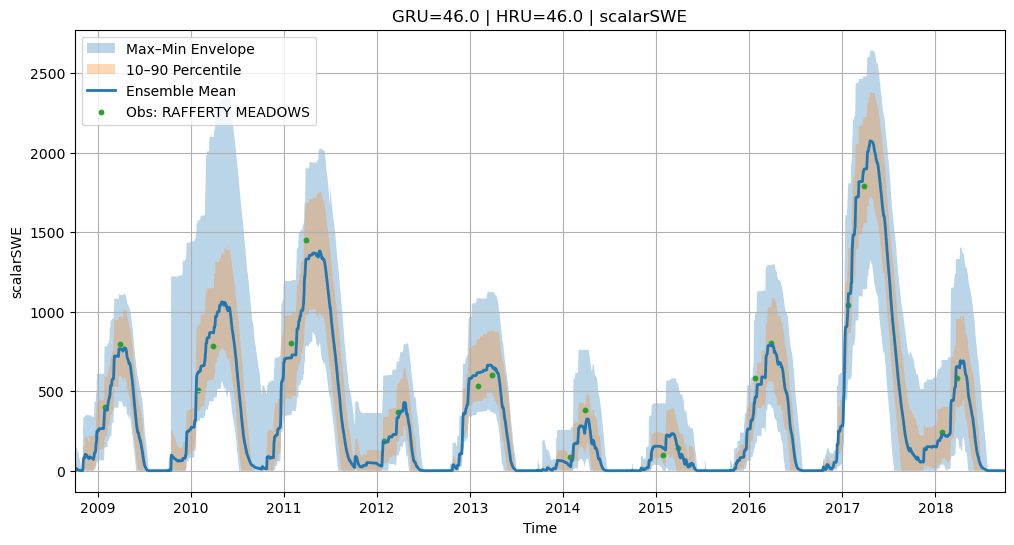

GRU_ID: 073


/tmp/ipykernel_3779538/3416380263.py:49: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 500. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(path, chunks={'time': 500})
/tmp/ipykernel_3779538/3416380263.py:49: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 500. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(path, chunks={'time': 500})
/tmp/ipykernel_3779538/3416380263.py:49: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 500. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(path, chunks={'time': 500})
/tmp/ipykernel_3779538/3416380263.py:49: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 500. This could degrade performa

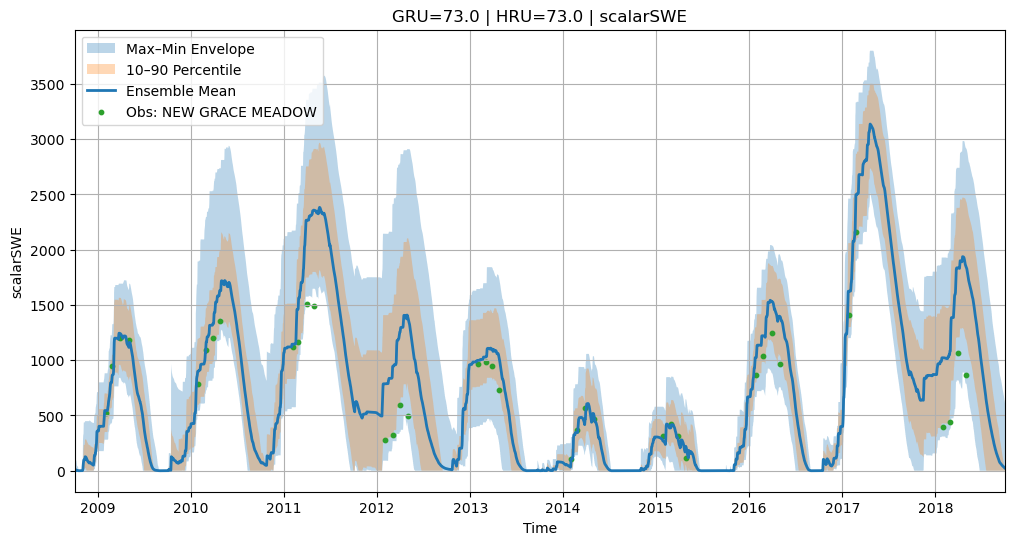

GRU_ID: 088


/tmp/ipykernel_3779538/3416380263.py:49: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 500. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(path, chunks={'time': 500})
/tmp/ipykernel_3779538/3416380263.py:49: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 500. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(path, chunks={'time': 500})
/tmp/ipykernel_3779538/3416380263.py:49: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 500. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(path, chunks={'time': 500})
/tmp/ipykernel_3779538/3416380263.py:49: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 500. This could degrade performa

In [ ]:
import os
import pandas as pd
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

def read_station_data_by_gru(ds, gru_id, station_id_to_gru):
    """
    Get a dictionary of station observations for a given GRU_ID.

    Parameters:
    - ds (xarray.Dataset): Dataset containing SWE observations for multiple stations
    - gru_id (int or str): The GRU_ID to filter by
    - station_id_to_gru (pd.DataFrame): DataFrame mapping 'station_id' to 'GRU_ID'

    Returns:
    - dict: {station_name: snw DataArray}
    """
    # Get station_ids for this GRU
    matching_ids = station_id_to_gru[station_id_to_gru['GRU_ID'] == gru_id]['station_id'].values

    # Ensure station_id and station_name are loaded first
    station_ids = ds['station_id'].load().values
    station_names = ds['station_name'].load().values  # Explicitly load this!

    # Get matching indices
    matching_indices = [i for i, sid in enumerate(station_ids) if sid in matching_ids]

    # Use isel to extract matching stations
    snw_subset = ds['snw'].isel(station_id=matching_indices).load()

    return {
        str(station_names[i]): snw_subset.isel(station_id=j)
        for j, i in enumerate(matching_indices)
    }
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from dask import compute  # <— import this

def plot_ensemble_and_stations(netcdf_files, station_data_dict,
                               variable_name, hru_id, output_path):
    # 1) Open & slice each file lazily
    das = []
    for path in netcdf_files:
        ds = xr.open_dataset(path)
        if variable_name in ds and 'hru' in ds.dims and hru_id in ds['hru']:
            das.append(ds[variable_name].sel(hru=hru_id))
    if not das:
        print(f"No ensemble data found for HRU {hru_id}")
        return

    # 2) Concatenate into a single DataArray
    ensemble = xr.concat(
        das,
        dim='member',
        join='outer',
        compat='override',
        coords='minimal'
    )

    # 3) Rechunk member → 1 block so reductions are legal
    ensemble = ensemble.chunk({'member': -1})

    # 4) Build your stats (lazy)
    mean_da =    ensemble.mean(dim='member')
    p10_da  =    ensemble.quantile(0.1, dim='member')
    p90_da  =    ensemble.quantile(0.9, dim='member')
    vmin_da =    ensemble.min(dim='member')
    vmax_da =    ensemble.max(dim='member')

    # 5) Compute all at once with Dask
    mean, p10, p90, vmin, vmax = compute(mean_da, p10_da, p90_da, vmin_da, vmax_da)
    time = ensemble['time'].values

    # 6) Plot
    plt.figure(figsize=(12, 6))
    plt.fill_between(time, vmin, vmax, alpha=0.3, label='Max–Min Envelope')
    plt.fill_between(time, p10,  p90,  alpha=0.3, label='10–90 Percentile')
    plt.plot(time,   mean,       linewidth=2, label='Ensemble Mean')
    for name, data in station_data_dict.items():
        plt.scatter(data['time'], data.values, s=10, label=f"Obs: {name}")

    plt.title(f"GRU={gru_id} | HRU={hru_id} | {variable_name}")
    plt.xlabel("Time")
    plt.ylabel(variable_name)
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.xlim(mdates.datestr2num('2008-10-01'),
             mdates.datestr2num('2018-10-01'))
    plt.savefig(output_path)
    plt.show()
    plt.close()
# -----------------------------
# Configuration
netcdf_directory = f'/anvil/projects/x-ees240082/users/dcasson/gpep/{catchment}/ensemble_generation/rf_best_regression_static_dynamic/summa/output/'
figure_directory = Path(f'/anvil/projects/x-ees240082/users/dcasson/gpep/{catchment}/ensemble_generation/rf_best_regression_static_dynamic/summa/swe_figures/')
variable_name = 'scalarSWE'
run_type = 'base'
z_fill = 3


figure_directory.mkdir(exist_ok=True)

# Load datasets
SWE_stations_ds_complete = xr.open_dataset(swe_observations_path)

SWE_stations_ds = filter_stations_by_obs_per_year(SWE_stations_ds_complete, var='snw', n=0, start_date=start_date, end_date=end_date)
hru_ids = pd.read_csv(hru_csv_path)  # must contain columns: station_id, HRU_ID, GRU_ID

# Map GRU_IDs from hru_ids for stations in SWE_stations_ds
station_ids_in_ds = SWE_stations_ds['station_id'].values
station_id_to_gru = hru_ids[hru_ids['station_id'].isin(station_ids_in_ds)]
unique_gru_ids = station_id_to_gru['GRU_ID'].unique()

# -----------------------------
# Loop over GRU_IDs
for gru_id in unique_gru_ids:
    station_data_dict = read_station_data_by_gru(SWE_stations_ds, gru_id, station_id_to_gru)
    if not station_data_dict:
        print(f"No stations found for GRU_ID {gru_id}")
        continue

    print(f"GRU_ID: {str(int(gru_id)).zfill(z_fill)}")
    # Filter files with G{GRU_ID} in filename
    netcdf_files = [
        os.path.join(netcdf_directory, f)
        for f in os.listdir(netcdf_directory)
        if f.endswith('.nc') and f"G{str(int(gru_id)).zfill(z_fill)}" in f
    ]

    if not netcdf_files:
        print(f"No ensemble files found for GRU_ID {gru_id}")
        continue

    # Pick the first HRU_ID associated with this GRU_ID
    hru_matches = hru_ids[hru_ids['GRU_ID'] == gru_id]['HRU_ID'].values
    if len(hru_matches) == 0:
        print(f"No HRU_ID found for GRU_ID {gru_id}")
        continue
    hru_id = int(hru_matches[0])

    # Output figure
    output_plot_path = figure_directory / f'ensemble_plot_GRU_{int(gru_id)}_HRU_{hru_id}_{run_type}_param.png'
    plot_ensemble_and_stations(netcdf_files, station_data_dict, variable_name, gru_id, output_plot_path)

  Plotting 'RF Static Dynamic' (deterministic=False) for HRU 1011.0
  Plotting 'LWR Static' (deterministic=False) for HRU 1011.0
  Plotting 'CASR' (deterministic=True) for HRU 1011.0


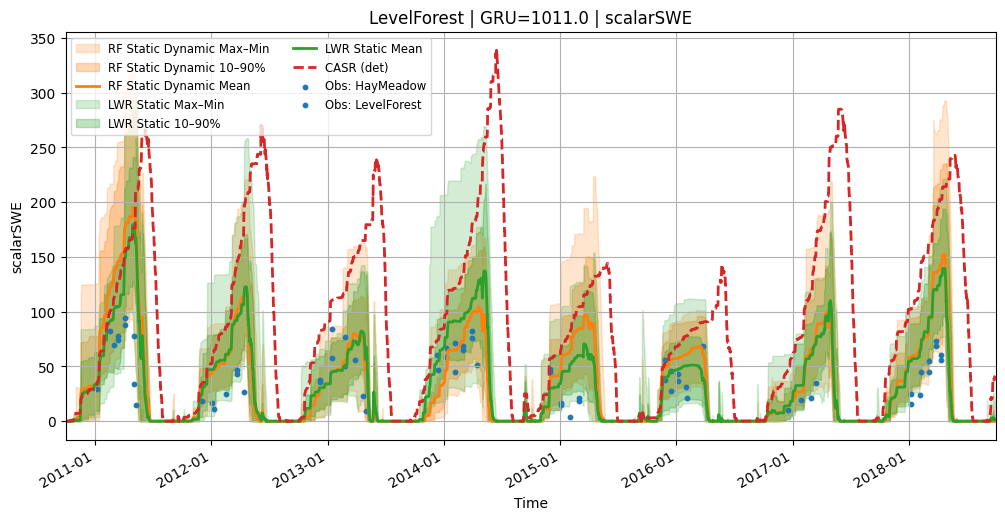

  Plotting 'RF Static Dynamic' (deterministic=False) for HRU 1163.0
  Plotting 'LWR Static' (deterministic=False) for HRU 1163.0
  Plotting 'CASR' (deterministic=True) for HRU 1163.0


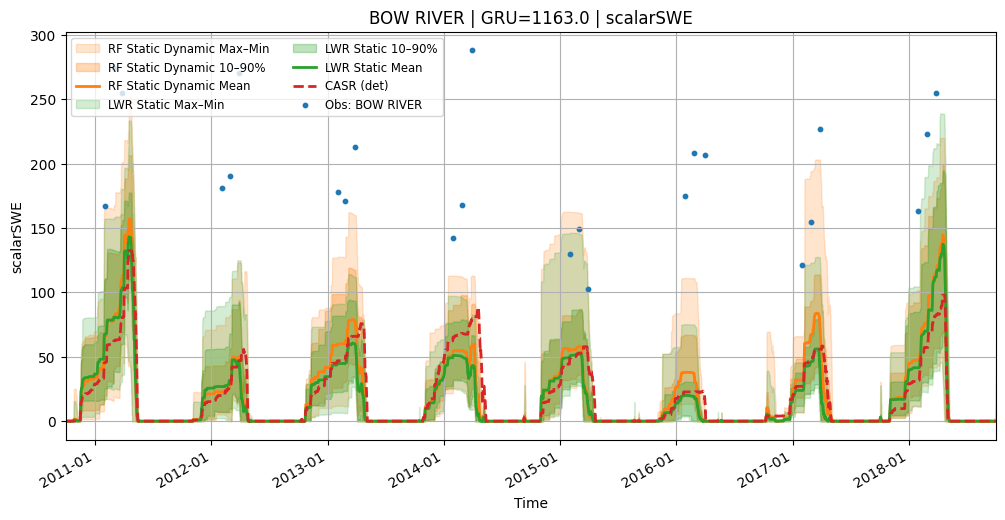

  Plotting 'RF Static Dynamic' (deterministic=False) for HRU 1024.0


In [ ]:
import os
import pandas as pd
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
from dask import compute


def read_station_data_by_gru(ds, gru_id, station_id_to_gru):
    matching_ids = station_id_to_gru[station_id_to_gru['GRU_ID'] == gru_id]['station_id'].values
    station_ids = ds['station_id'].load().values
    station_names = ds['station_name'].load().values
    matching_indices = [i for i, sid in enumerate(station_ids) if sid in matching_ids]
    snw_subset = ds['snw'].isel(station_id=matching_indices).load()
    return {
        str(station_names[i]): snw_subset.isel(station_id=j)
        for j, i in enumerate(matching_indices)
    }


def plot_multiple_ensembles(ensemble_specs, station_data_dict,
                            variable_name, hru_id, output_path,
                            time_range=None):
    fig, ax = plt.subplots(figsize=(12, 6))

    for spec in ensemble_specs:
        label = spec['label']
        files = spec['files']
        color = spec.get('color', 'k')
        is_det = spec.get('deterministic', False)

        print(f"  Plotting '{label}' (deterministic={is_det}) for HRU {hru_id}")

        if is_det:
            # --- deterministic: just one file, one line ---
            nc = files[0]
            ds = xr.open_dataset(nc, chunks={'time': 500})
            hru_dim = next((d for d in ds.dims if d.lower().startswith('hru')), None)
            da = ds[variable_name].sel({hru_dim: hru_id})
            time = da['time'].values
            vals = da.values
            ax.plot(time, vals,
                    color=color, linestyle='--', linewidth=2,
                    label=f"{label} (det)")
            continue

        # --- ensemble: build lazy, chunked member×time array ---
        das = []
        for nc in files:
            ds = xr.open_dataset(nc, chunks={'time': 500})
            if variable_name not in ds:
                continue
            hru_dim = next((d for d in ds.dims if d.lower().startswith('hru')), None)
            da = ds[variable_name].sel({hru_dim: hru_id})
            das.append(da)

        if not das:
            print(f"    No members for '{label}', skipping")
            continue

        ensemble = xr.concat(
            das,
            dim='member',
            join='outer',
            compat='override',
            coords='minimal'
        ).chunk({'member': -1})

        # lazy stats
        mean_da = ensemble.mean(dim='member')
        p10_da  = ensemble.quantile(0.1, dim='member')
        p90_da  = ensemble.quantile(0.9, dim='member')
        vmin_da = ensemble.min(dim='member')
        vmax_da = ensemble.max(dim='member')

        mean, p10, p90, vmin, vmax = compute(mean_da, p10_da, p90_da, vmin_da, vmax_da)
        time = ensemble['time'].values

        ax.fill_between(time, vmin, vmax,
                        color=color, alpha=0.2,
                        label=f"{label} Max–Min")
        ax.fill_between(time, p10, p90,
                        color=color, alpha=0.3,
                        label=f"{label} 10–90%")
        ax.plot(time, mean,
                color=color, linewidth=2,
                label=f"{label} Mean")

    # station obs
    for name, da in station_data_dict.items():
        ax.scatter(da['time'], da.values,
                   label=f"Obs: {name}", s=10, color='C0')

    ax.set_title(f"{name} | GRU={gru_id} | {variable_name}")
    ax.set_xlabel("Time")
    ax.set_ylabel(variable_name)
    ax.legend(loc='upper left', fontsize='small', ncol=2)
    ax.grid(True)

    if time_range:
        start, end = time_range
        ax.set_xlim(mdates.datestr2num(start), mdates.datestr2num(end))

    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    fig.autofmt_xdate()

    Path(output_path).parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(output_path, bbox_inches='tight')
    plt.show()
    plt.close(fig)


# -----------------------------
# Configuration
ensemble_sources = [
    {
        'label': 'RF Static Dynamic',
        'dir': f'/anvil/projects/x-ees240082/users/dcasson/gpep/{catchment}/ensemble_generation/rf_best_regression_static_dynamic/summa/output/',
        'color': 'C1',
        'deterministic': False
    },
    {
        'label': 'LWR Static',
        'dir': f'/anvil/projects/x-ees240082/users/dcasson/gpep/{catchment}/ensemble_generation/lwr_best_regression_static/summa/output/',
        'color': 'C2',
        'deterministic': False
    },
    {
        'label': 'CASR',
        'dir': f'/anvil/projects/x-ees240082/users/dcasson/gpep/{catchment}/ensemble_generation/casr_remapped/summa_output',
        'color': 'C3',
        'deterministic': True
    },
    
    # Add more sources here as needed
]
figure_directory = Path('/anvil/projects/x-ees240082/users/{catchment}/ensemble_generation/swe_figures_rf_compare/')
figure_directory.mkdir(parents=True, exist_ok=True)
variable_name = 'scalarSWE'
# load stations
SWE_stations_ds_complete = xr.open_dataset(swe_observations_path)
SWE_stations_ds = filter_stations_by_obs_per_year(
    SWE_stations_ds_complete, var='snw', n=0,
    start_date=start_date, end_date=end_date
)

hru_ids = pd.read_csv(hru_csv_path)
station_ids_in_ds = SWE_stations_ds['station_id'].values
station_id_to_gru = hru_ids[hru_ids['station_id'].isin(station_ids_in_ds)]
unique_gru_ids = station_id_to_gru['GRU_ID'].unique()

for gru_id in unique_gru_ids:
    station_data = read_station_data_by_gru(
        SWE_stations_ds, gru_id, station_id_to_gru
    )
    if not station_data:
        continue

    specs = []
    for src in ensemble_sources:
        files = [
            os.path.join(src['dir'], f)
            for f in os.listdir(src['dir'])
            if f.endswith('.nc') and f"G{int(gru_id):03d}" in f
        ]
        if files:
            specs.append({'label': src['label'],
                          'files': files,
                          'color': src['color'],
                          'deterministic': src['deterministic']})

    if not specs:
        continue

    hru_match = hru_ids[hru_ids['GRU_ID'] == gru_id]['HRU_ID'].values
    if hru_match.size == 0:
        continue
    hru_id = int(hru_match[0])

    out = figure_directory / f"compare_GRU_{int(gru_id):04d}_HRU_{hru_id}.png"
    plot_multiple_ensembles(
        specs, station_data, variable_name,
        gru_id, out,
        time_range=('2010-10-01', '2018-10-01')
    )


In [ ]:
import os
import pandas as pd
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
from typing import Union
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy.stats import pearsonr, spearmanr

# --- Statistical metrics ---
def mae(obs: Union[np.ndarray, pd.Series], sim: Union[np.ndarray, pd.Series]) -> float:
    obs_arr = np.asarray(obs, dtype=float).ravel()
    sim_arr = np.asarray(sim, dtype=float).ravel()  
    mask = ~np.isnan(obs_arr) & ~np.isnan(sim_arr)
    if mask.sum() == 0:
        return np.nan
    return mean_absolute_error(obs_arr[mask], sim_arr[mask])

def rmse(obs: Union[np.ndarray, pd.Series], sim: Union[np.ndarray, pd.Series]) -> float:
    obs_arr = np.asarray(obs, dtype=float).ravel()
    sim_arr = np.asarray(sim, dtype=float).ravel()
    mask = ~np.isnan(obs_arr) & ~np.isnan(sim_arr)
    if mask.sum() == 0:
        return np.nan
    return mean_squared_error(obs_arr[mask], sim_arr[mask], squared=False)

def corr_Pearson(obs: Union[np.ndarray, pd.Series], sim: Union[np.ndarray, pd.Series]) -> float:
    obs_arr = np.asarray(obs, dtype=float).ravel()
    sim_arr = np.asarray(sim, dtype=float).ravel()
    mask = ~np.isnan(obs_arr) & ~np.isnan(sim_arr)
    if mask.sum() < 2:
        return np.nan
    return pearsonr(obs_arr[mask], sim_arr[mask])[0]

def corr_Spearman(obs: Union[np.ndarray, pd.Series], sim: Union[np.ndarray, pd.Series]) -> float:
    obs_arr = np.asarray(obs, dtype=float).ravel()
    sim_arr = np.asarray(sim, dtype=float).ravel()
    mask = ~np.isnan(obs_arr) & ~np.isnan(sim_arr)
    if mask.sum() < 2:
        return np.nan
    return spearmanr(obs_arr[mask], sim_arr[mask])[0]

def nrmse_adimMax(obs: Union[np.ndarray, pd.Series], sim: Union[np.ndarray, pd.Series]) -> float:
    obs_arr = np.asarray(obs, dtype=float).ravel()
    sim_arr = np.asarray(sim, dtype=float).ravel()
    mask = ~np.isnan(obs_arr) & ~np.isnan(sim_arr)
    if mask.sum() == 0:
        return np.nan
    e = rmse(obs_arr[mask], sim_arr[mask])
    max_obs = np.nanmax(obs_arr[mask])
    return e / max_obs if max_obs != 0 else np.nan

def nrmse_adimSD(obs: Union[np.ndarray, pd.Series], sim: Union[np.ndarray, pd.Series]) -> float:
    obs_arr = np.asarray(obs, dtype=float).ravel()
    sim_arr = np.asarray(sim, dtype=float).ravel()
    mask = ~np.isnan(obs_arr) & ~np.isnan(sim_arr)
    if mask.sum() == 0:
        return np.nan
    e = rmse(obs_arr[mask], sim_arr[mask])
    sd_obs = np.nanstd(obs_arr[mask], ddof=1)
    return e / sd_obs if sd_obs != 0 else np.nan

# --- Read station observations per GRU ---
def read_station_data_by_gru(ds, gru_id, station_map):
    ids = station_map.loc[station_map['GRU_ID'] == gru_id, 'station_id'].values
    station_ids = ds['station_id'].load().values
    station_names = ds['station_name'].load().values
    indices = [i for i, sid in enumerate(station_ids) if sid in ids]
    snw = ds['snw'].isel(station_id=indices).load()
    return {
        str(station_names[i]): snw.isel(station_id=j)
        for j, i in enumerate(indices)
    }


# --- Plot ensemble vs observations, with deterministic support ---
def plot_multiple_ensembles(ensemble_specs, station_data, var_name,
                            output_path, time_range=None):
    fig, ax = plt.subplots(figsize=(12, 6))

    for spec in ensemble_specs:
        label = spec['label']
        files = spec['files']
        color = spec.get('color', 'k')
        is_det = spec.get('deterministic', False)

        print(f"Plotting source '{label}' (deterministic={is_det})")

        if is_det:
            # single deterministic file
            ds = xr.open_dataset(files[0])
            da = ds[var_name].resample(time='1D').mean()
            time = da['time'].values
            vals = da.values
            ax.plot(time, vals,
                    linestyle='--', linewidth=2,
                    color=color, label=f"{label} (det)")
            continue

        # ensemble processing
        ensemble_vals = []
        time = None
        for nc in files:
            print(f"  Loading {nc}")
            ds = xr.open_dataset(nc)
            if var_name not in ds:
                continue
            daily = ds[var_name].resample(time='1D').mean()
            ensemble_vals.append(daily.values)
            if time is None:
                time = daily['time'].values

        if not ensemble_vals:
            print(f"  No data for '{label}', skipping")
            continue

        arr = np.array(ensemble_vals)
        mean = np.nanmean(arr, axis=0)
        p10, p90 = np.nanpercentile(arr, [10, 90], axis=0)
        vmin, vmax = np.nanmin(arr, axis=0), np.nanmax(arr, axis=0)

        ax.fill_between(time, vmin, vmax,
                        color=color, alpha=0.2,
                        label=f"{label} max–min")
        ax.fill_between(time, p10, p90,
                        color=color, alpha=0.3,
                        label=f"{label} 10–90th pct")
        ax.plot(time, mean,
                color=color, linewidth=2,
                label=f"{label} mean")

    print("Plotting station observations...")
    for name, da in station_data.items():
        ax.scatter(da['time'], da.values,
                   s=10, label=f"Obs {name}")

    ax.set_xlabel('Time')
    ax.set_ylabel(var_name)
    if time_range:
        ax.set_xlim(mdates.datestr2num(time_range[0]),
                    mdates.datestr2num(time_range[1]))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    fig.autofmt_xdate()
    ax.grid(True)
    ax.legend(loc='upper left', fontsize='small', ncol=2)

    Path(output_path).parent.mkdir(parents=True, exist_ok=True)
    print(f"Saving figure to {output_path}")
    plt.savefig(output_path, bbox_inches='tight')
    plt.close(fig)

# --- CDF of metrics ---
def plot_metrics_cdf(df, metric, output_path):
    fig, ax = plt.subplots(figsize=(8, 4))
    for src in df['Source'].unique():
        vals = df.loc[df['Source'] == src, metric].dropna().values
        if len(vals) == 0:
            continue
        sorted_vals = np.sort(vals)
        ecdf = np.arange(1, len(sorted_vals) + 1) / len(sorted_vals)
        ax.plot(sorted_vals, ecdf, label=src)
    ax.set_title(f"CDF of {metric}")
    ax.set_xlabel(metric)
    ax.set_ylabel('ECDF')
    ax.grid(True)
    ax.legend()
    Path(output_path).parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(output_path, bbox_inches='tight')
    plt.close(fig)

# --- Main processing ---
if __name__ == "__main__":
    catchment = 'bow'
    # Configuration
    ensemble_sources = [
    {
        'label': 'RF Static Dynamic',
        'dir': f'/anvil/projects/x-ees240082/users/dcasson/gpep/{catchment}/ensemble_generation/rf_best_regression_static_dynamic/summa/output/',
        'color': 'C1',
        'deterministic': False
    },
    {
        'label': 'LWR Static',
        'dir': f'/anvil/projects/x-ees240082/users/dcasson/gpep/{catchment}/ensemble_generation/lwr_best_regression_static/summa/output/',
        'color': 'C2',
        'deterministic': False
    },
    {
        'label': 'CASR',
        'dir': f'/anvil/projects/x-ees240082/users/dcasson/gpep/{catchment}/ensemble_generation/casr_remapped/summa_output',
        'color': 'C3',
        'deterministic': True
    },
    
    # Add more sources here as needed
]
    swe_obs_path = '/anvil/projects/x-ees240082/users/dcasson/gpep/bow/snow_data/bow_NorSWE.nc'
    hru_csv_path = '/anvil/projects/x-ees240082/users/dcasson/gpep/bow/gis/stations_with_hru_ids.csv'
    variable_name = 'scalarSWE'
    figure_dir = Path('./swe_figures/')
    metrics_csv = 'ensemble_metrics_hidden_stations.csv'
    metrics_cdf_dir = Path('./metrics_cdf/')
    time_range=('2008-10-01','2018-10-01')
    
    # Load and filter observations
    ds_obs  = xr.open_dataset(swe_obs_path)
    ds_filt = filter_stations_by_obs_per_year(
        ds_obs, var='snw', n=1,
        start_date=time_range[0], end_date=time_range[1]
    )
    hru_map     = pd.read_csv(hru_csv_path)
    station_map = hru_map[hru_map['station_id'].isin(ds_filt['station_id'].values)]
    unique_grus = station_map['GRU_ID'].unique()
    grus_to_exclude = [1024, 1163]

    unique_grus = [g for g in station_map['GRU_ID'].unique()
                if g not in grus_to_exclude]
    print(f"→ will process GRUs: {unique_grus}")
    metrics = []
    for gru in unique_grus:
        print(f"Processing GRU {gru}")
        station_data = read_station_data_by_gru(ds_filt, gru, station_map)
        if not station_data:
            continue

        # build specs for this GRU
        specs = []
        for src in ensemble_sources:
            files = [
                os.path.join(src['dir'], f)
                for f in os.listdir(src['dir'])
                if f.endswith('.nc') and f"G{int(gru):04d}" in f
            ]
            if files:
                specs.append({
                    'label':        src['label'],
                    'files':        files,
                    'color':        src['color'],
                    'deterministic': src['deterministic']
                })
        if not specs:
            continue

        # compute metrics for each source
        for spec in specs:
            label = spec['label']
            print(f"  Calculating metrics for {label}")

            if spec['deterministic']:
                # single run → daily mean
                ds = xr.open_dataset(spec['files'][0])
                daily = ds[variable_name].resample(time='1D').mean()
                mean_ts = daily.values
                mean_ts = np.squeeze(mean_ts) 
                sim_times = pd.to_datetime(daily['time'].values)
            else:
             # --- ENSEMBLE: build one Series per member, union times ---
                series_list = []
                for nc in spec['files']:
                    ds = xr.open_dataset(nc)
                    daily = ds[variable_name].resample(time='1D').mean()
                    times = pd.to_datetime(daily['time'].values)
                    vals = np.squeeze(daily.values)
                    series_list.append(pd.Series(vals, index=times))

                # union index, fill missing with NaN, then mean
                df_ens      = pd.concat(series_list, axis=1)
                mean_series = df_ens.mean(axis=1, skipna=True)

                sim_times = mean_series.index
                mean_ts    = mean_series.values
                mean_ts = np.squeeze(mean_ts) 

            # align observations & simulation by intersecting dates
            sim_series = pd.Series(mean_ts, index=sim_times)

            for name, da in station_data.items():
                obs_times = pd.to_datetime(da['time'].values)
                obs_series = pd.Series(da.values, index=obs_times)

                common_idx = obs_series.index.intersection(sim_series.index)
                if common_idx.empty:
                    continue

                obs_clean = obs_series.loc[common_idx].values
                sim_clean = sim_series.loc[common_idx].values
                n_obs = len(common_idx)

                metrics.append({
                    'GRU_ID':    gru,
                    'Station':   name,
                    'Source':    label,
                    'N_obs':     n_obs,
                    'MAE':       mae(obs_clean, sim_clean),
                    'RMSE':      rmse(obs_clean, sim_clean),
                    'Pearson':   corr_Pearson(obs_clean, sim_clean),
                    'Spearman':  corr_Spearman(obs_clean, sim_clean),
                    'NRMSE_max': nrmse_adimMax(obs_clean, sim_clean),
                    'NRMSE_sd':  nrmse_adimSD(obs_clean, sim_clean)
                })

    # Save metrics CSV
    df = pd.DataFrame(metrics)
    df.to_csv(metrics_csv, index=False)
    print(f"Saved metrics to {metrics_csv}")

    # Plot CDFs
    def plot_metrics_cdf(df, metric, output_path):
        fig, ax = plt.subplots(figsize=(8, 4))
        for src in df['Source'].unique():
            vals = df.loc[df['Source'] == src, metric].dropna().values
            if len(vals) == 0:
                continue
            sorted_vals = np.sort(vals)
            ecdf = np.arange(1, len(sorted_vals)+1) / len(sorted_vals)
            ax.plot(sorted_vals, ecdf, label=src)
        ax.set_title(f"CDF of {metric}")
        ax.set_xlabel(metric)
        ax.set_ylabel('ECDF')
        ax.grid(True)
        ax.legend()
        Path(output_path).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(output_path, bbox_inches='tight')
        plt.close(fig)

    for m in ['N_obs','MAE','RMSE','Pearson','Spearman','NRMSE_max','NRMSE_sd']:
        plot_metrics_cdf(df, m, metrics_cdf_dir / f"cdf_{m}.png")

    print(f"Generated CDFs in {metrics_cdf_dir}")


→ will process GRUs: [152.0, 141.0, 159.0, 770.0, 89.0, 245.0, 91.0, 184.0]
Processing GRU 152.0
  Calculating metrics for RF Static Dynamic
  Calculating metrics for LWR Static
  Calculating metrics for CASR
Processing GRU 141.0
  Calculating metrics for RF Static Dynamic
  Calculating metrics for LWR Static
  Calculating metrics for CASR
Processing GRU 159.0
  Calculating metrics for RF Static Dynamic
  Calculating metrics for LWR Static
  Calculating metrics for CASR
Processing GRU 770.0
  Calculating metrics for RF Static Dynamic
  Calculating metrics for LWR Static
  Calculating metrics for CASR
Processing GRU 89.0
  Calculating metrics for RF Static Dynamic
  Calculating metrics for LWR Static
  Calculating metrics for CASR
Processing GRU 245.0
  Calculating metrics for RF Static Dynamic
  Calculating metrics for LWR Static
  Calculating metrics for CASR
Processing GRU 91.0
  Calculating metrics for RF Static Dynamic
  Calculating metrics for LWR Static
  Calculating metrics for 

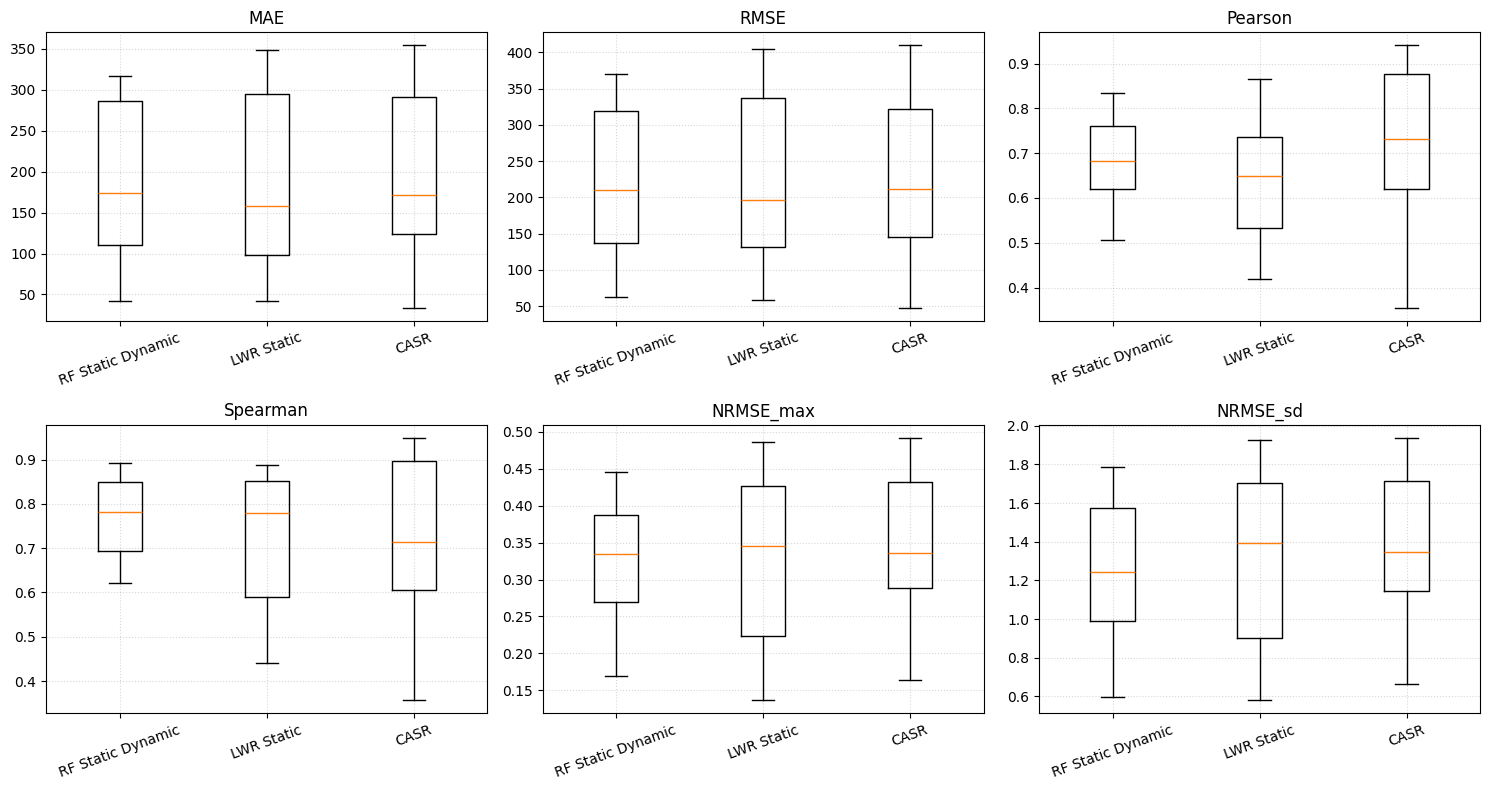

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# --- Load metrics CSV ---
metrics_csv = 'ensemble_metrics_hidden_stations.csv'
df = pd.read_csv(metrics_csv)

# --- Configuration ---
metrics = ['MAE','RMSE','Pearson','Spearman','NRMSE_max','NRMSE_sd']
sources = df['Source'].unique()
n = len(metrics)
ncols = 3
nrows = (n + ncols - 1)//ncols

# --- Plot ---
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5*ncols, 4*nrows))
axes = axes.flatten()

for ax, metric in zip(axes, metrics):
    # prepare data for each Source
    data = [ df.loc[df['Source']==src, metric].dropna().values
             for src in sources ]
    ax.boxplot(data, labels=sources, showfliers=False)
    ax.set_title(metric)
    ax.tick_params(axis='x', rotation=20)
    ax.grid(True, linestyle=':', alpha=0.5)

# hide any extra subplots
for ax in axes[n:]:
    ax.set_visible(False)

fig.tight_layout()
plt.savefig(Path('metrics_boxplots_grid.png'))
plt.show()